In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py

In [2]:
target_d_L = 75.4#Mpc

In [3]:
base = "IPTA_MDC2_G2D2_detection_"
crnr_plt_title1 =base+'corner plot_tref_corrected'
crnr_plt_title2 =base
trace_plot_title = base+'trace_plot'
BF_histogram_title = base+'log10A_histogram'
BFerr_title = base+'log10A_histogram_error'

In [4]:
pwd

'/scratch/na00078/projects/IPTA_MDC2/post_processing'

## Generate Outfile

## Run Outfile

In [5]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_narrow_detect_tref_outfile.h5"
infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_narrow_detect_tref_outfile.h5
8
(100000000, 8)
(1, 100000000)


## Corner Plots

In [6]:
KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx0 = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":0.8412486994612669,
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":np.log10(3.7e-09),
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651,
        "distance": 75.4,}


xxx = {
       "0_cos_inc":0.8412486994612669,
        "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651}

xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.070581074285707
    
#print(xxx)

# In[6]:




hamp [7.2932440e-18 3.4708954e-16 5.1483155e-16 ... 4.5982027e-14 4.5982027e-14
 4.4218416e-14]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [1.9023741e+09 1.4594280e+08 4.1082332e+09 ... 2.3782625e+09 2.3782625e+09
 2.3782625e+09]
Length of logdL 100000000
required values 8.470148 3.7000025e-09 145942800.0 2.2741503e-14
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [5.6930359e+04 1.6569187e+01 2.9098110e+03 ... 1.3100356e+01 1.3100356e+01
 1.3622852e+01]
min 10**log10_d_L 0.0008424003
max 10**log10_d_L 295221570.0
d_L_mask [    9419    12096    12237 ... 99999949 99999962 99999965]
notd_L_mask1 [       1       36       52 ... 99999997 99999998 99999999]
notd_L_mask2 [       0        2        3 ... 99999872 99999924 99999928]
merged_non_dL [       1       36       52 ... 99999872 99999924 99999928]
Sample shape (100000000, 9)
dL_mask length 118567
5
Max Mc sampled 10.013484
Recovered Φ0 mean = 4.476207 rad
Recovered ψ mean  =

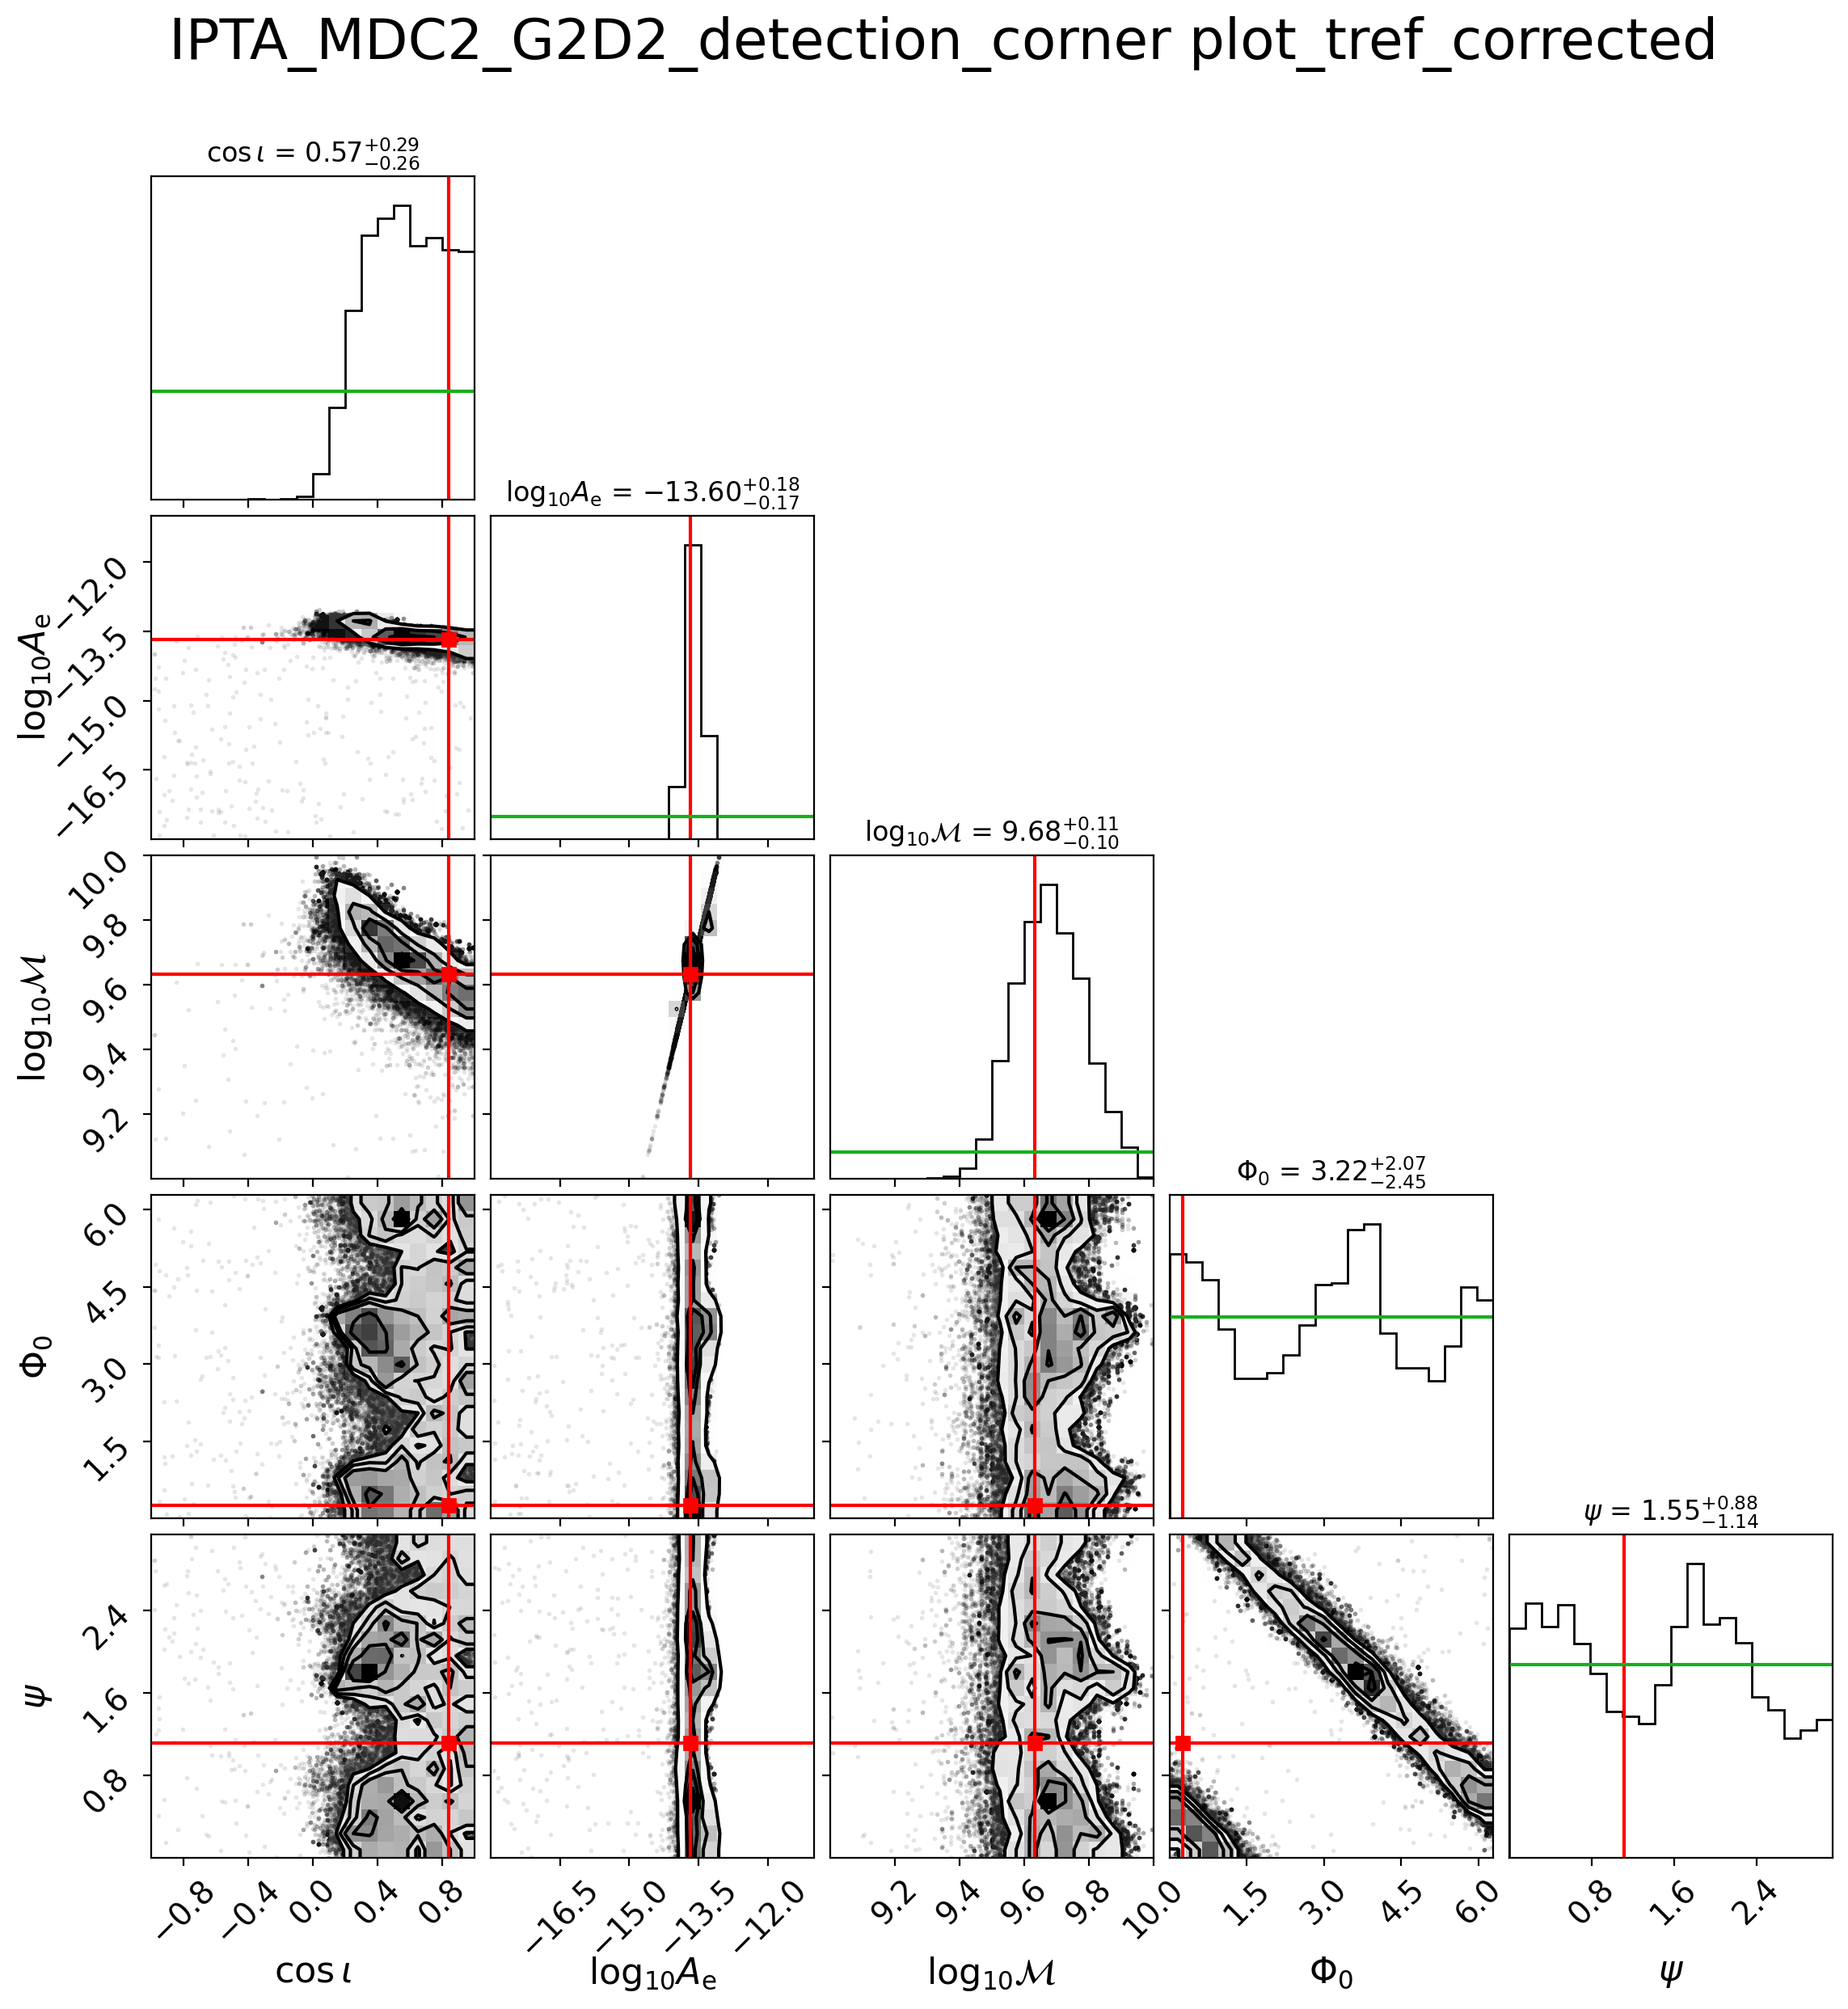

In [7]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
#labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
      #    r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
labels = [r"$\cos \iota$", r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$",r"$\psi$"]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}

# Now build the truths array by translating labels
truths = [xxx[label_to_key[l]] for l in labels]


#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-18,-11), (9,10), (0,2*np.pi), (0,np.pi)]
#ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.704,np.log10(3e-7)), (-18,-11), (6.6,12), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################

d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

print("Max Mc sampled", np.max(samples2plot[d_L_mask,5]))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                          samples2plot[d_L_mask,4],
                          samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T


#fig = corner.corner(samples2plot_detect,
  #                  labels=labels,
   #                 show_titles=True, quantiles=[0.16, 0.5, 0.84],
    #                range=ranges, hist_kwargs={"density":True})
    

fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"   # optional, highlights them in red
)

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)   # tick labels
    ax.xaxis.label.set_size(16)                 # x-axis label
    ax.yaxis.label.set_size(16)                 # y-axis label

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    #elif i==3*(len(labels)+1): #log10_fgw
     #   Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
      #  ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==3*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==4*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

fig.suptitle(crnr_plt_title1, fontsize = 25,y=1.05);

# --- compute posterior means from the thinned, dL-masked samples ---
phase0_samples = samples2plot[d_L_mask, 6]   # column index for Φ0
psi_samples    = samples2plot[d_L_mask, 7]   # column index for ψ

# convert angular parameters to circular means
def circ_mean(x, period):
    """Circular mean on [0, period)"""
    return np.angle(np.mean(np.exp(1j * 2*np.pi * x / period))) * period / (2*np.pi) % period

phi0_rec_mean = circ_mean(phase0_samples, 2*np.pi)
psi_rec_mean  = circ_mean(psi_samples, np.pi)

print(f"Recovered Φ0 mean = {phi0_rec_mean:.6f} rad")
print(f"Recovered ψ mean  = {psi_rec_mean:.6f} rad")


Truth Φ₀ = 3.3859391488689994
Truth ψ  = 1.1187560505283651
Median Φ₀ (corr) = 3.08009e+00
Median ψ  (corr) = 1.5470697


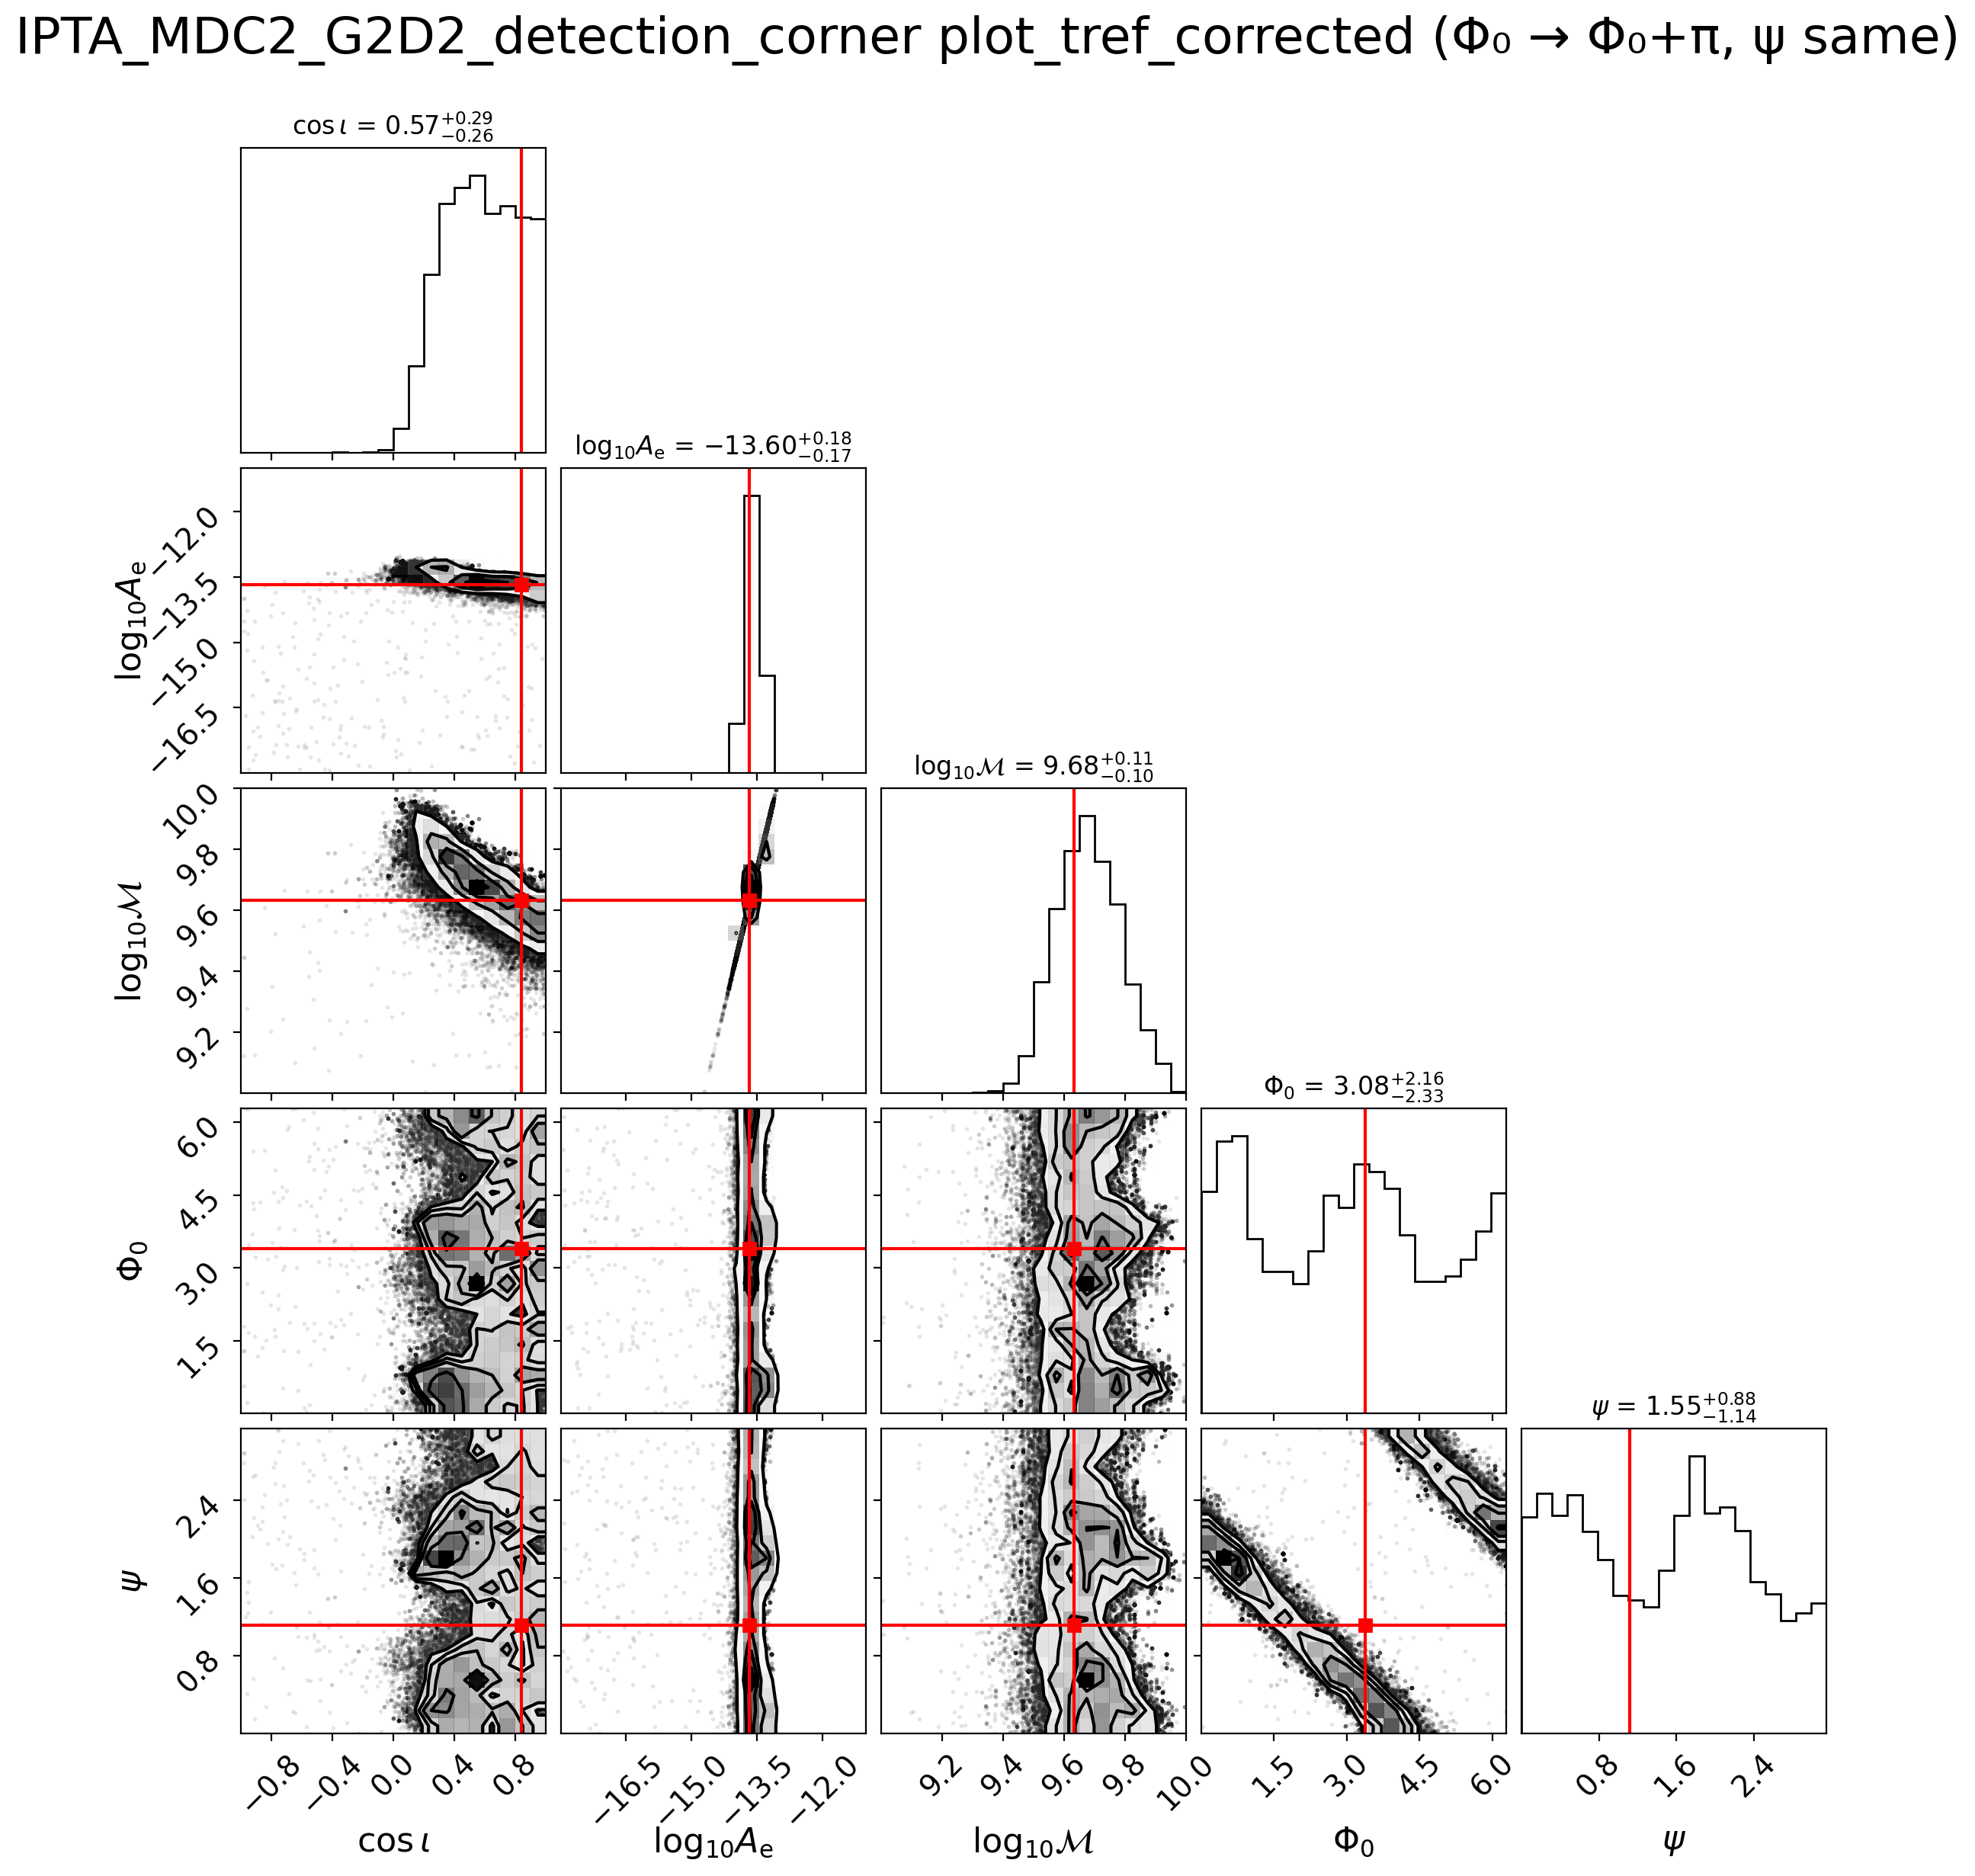

In [21]:
import numpy as np
import corner

# --- labels and axis ranges ---
labels = [r"$\cos \iota$", r"$\log_{10} A_{\rm e}$",
          r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$"]
ranges = [(-1, 1), (-18, -11), (9, 10), (0, 2*np.pi), (0, np.pi)]

# --- pull out masked samples ---
cosi   = samples_cold[0][burnin::thin, 1][d_L_mask]
logAe  = samples_cold[0][burnin::thin, 4][d_L_mask]
logMc  = samples_cold[0][burnin::thin, 5][d_L_mask]
phase0_s = samples_cold[0][burnin::thin, 6][d_L_mask]
psi_s    = samples_cold[0][burnin::thin, 7][d_L_mask]

# === 1) Apply the verified convention ===
#   δ = 0   → keep ψ unchanged
#   Φ₀ offset = +π  → wrap back to [0, 2π)
phi_corr = (phase0_s + np.pi) % (2*np.pi)
psi_corr = psi_s % np.pi

samples2plot_detect = np.vstack((cosi, logAe, logMc, phi_corr, psi_corr)).T

# === 2) Injection (truth) values ===
# Use the translated injection you computed earlier:
phi_truth = 3.3859391488689995   # Φ₀_inj_qc = Φ₀_inj + π
psi_truth = 1.1187560505283651   # ψ_inj_qc (same as original)

# These come directly from your dataset_2 params
cosi_truth  = xxx["0_cos_inc"]
logAe_truth = xxx["0_log10_h"]
logMc_truth = xxx["0_log10_mc"]

truths = [cosi_truth, logAe_truth, logMc_truth, phi_truth, psi_truth]

# === 3) Plot corner ===
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"
)

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

fig.suptitle(crnr_plt_title1 + " (Φ₀ → Φ₀+π, ψ same)", fontsize=24, y=1.04)

# Debug check
print("Truth Φ₀ =", phi_truth)
print("Truth ψ  =", psi_truth)
print("Median Φ₀ (corr) =", np.median(phi_corr))
print("Median ψ  (corr) =", np.median(psi_corr))


In [22]:
# Chi captures the identified combo; should peak sharply at truth.
phi0 = phi_corr                 # your Φ0 samples after +π, in [0, 2π)
psi  = psi_corr                 # your ψ samples in [0, π)

# Choose a reference φ_F = atan2(Fx, Fp) if you want per-pulsar precision.
# For a quick global check, set φ_F = 0; it only shifts chi by a constant.
phiF = 0.0

chi_samples = (2*psi - phi0 - phiF) % (2*np.pi)
chi_truth   = (2*1.1187560505283651 - 3.3859391488689995 - phiF) % (2*np.pi)

print("chi truth =", chi_truth)
print("chi circular mean =", np.angle(np.mean(np.exp(1j*chi_samples))) % (2*np.pi))


chi truth = 5.134758259367317
chi circular mean = 3.615849320088522


hamp [7.2932440e-18 3.4708954e-16 5.1483155e-16 ... 4.5982027e-14 4.5982027e-14
 4.4218416e-14]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [1.9023741e+09 1.4594280e+08 4.1082332e+09 ... 2.3782625e+09 2.3782625e+09
 2.3782625e+09]
Length of logdL 100000000
required values 8.470148 3.7000025e-09 145942800.0 2.2741503e-14
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [5.6930359e+04 1.6569187e+01 2.9098110e+03 ... 1.3100356e+01 1.3100356e+01
 1.3622852e+01]
min 10**log10_d_L 0.0008424003
max 10**log10_d_L 295221570.0
d_L_mask [    9419    12096    12237 ... 99999949 99999962 99999965]
notd_L_mask1 [       1       36       52 ... 99999997 99999998 99999999]
notd_L_mask2 [       0        2        3 ... 99999872 99999924 99999928]
merged_non_dL [       1       36       52 ... 99999872 99999924 99999928]
Sample shape (100000000, 9)
dL_mask length 118567
9


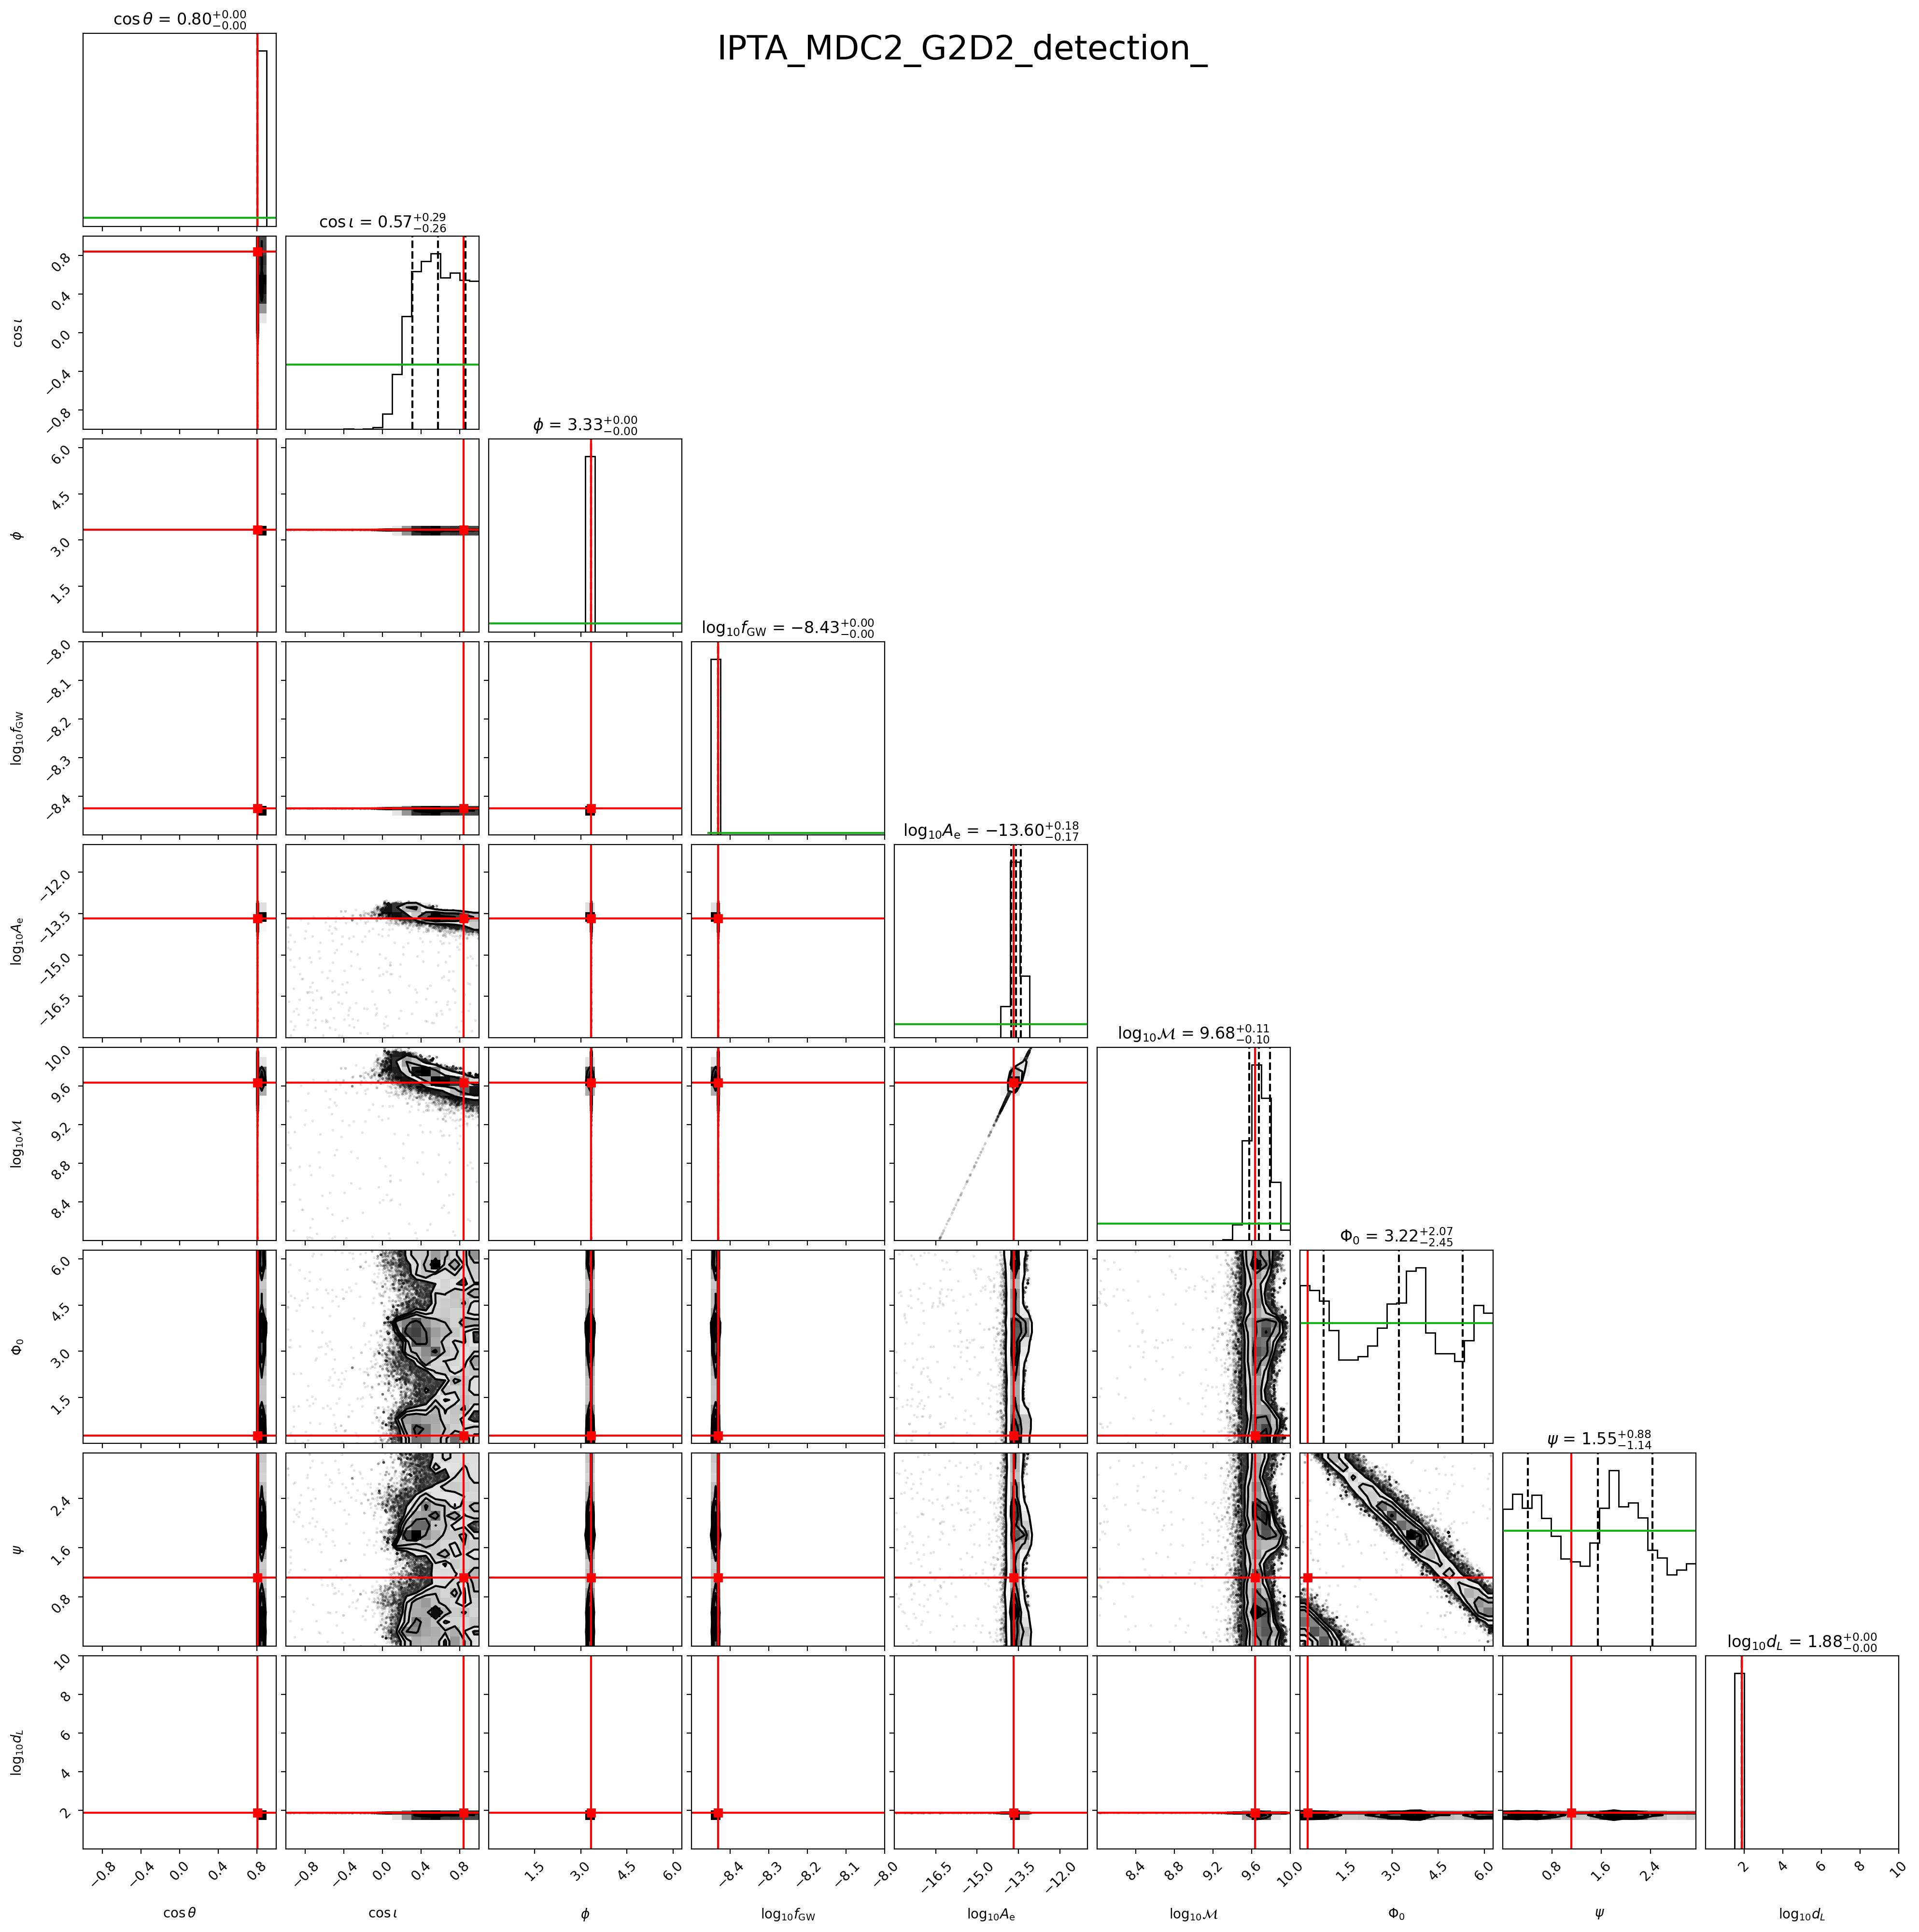

In [10]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
          r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
          
# Mapping from pretty labels → xxx0 keys
label_to_key = {
    r"$\cos \theta$": "0_cos_gwtheta",
    r"$\cos \iota$": "0_cos_inc",
    r"$\phi$": "0_gwphi",
    r"$\log_{10} f_{\rm GW}$": "0_log10_fgw",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi",
    r"$\log_{10} d_L$": "distance"
}

# Build truths list (log-transform distance for d_L)
truths = []
for lab in labels:
    key = label_to_key[lab]
    if lab == r"$\log_{10} d_L$":
        truths.append(np.log10(xxx0[key]))
    else:
        truths.append(xxx0[key])
        
#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.5,-8), (-18,-11), (8,10), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################

d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

#fig = corner.corner(samples2plot[d_L_mask, :],
 #                   labels=labels,
  #                  show_titles=True, quantiles=[0.16, 0.5, 0.84],
   #                 range=ranges, hist_kwargs={"density":True})

fig = corner.corner(
    samples2plot[d_L_mask, :],   # <-- use samples2plot, not samples2plot_detect
    labels=labels,
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"
)

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0 or i==(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==2*(len(labels)+1) or i==6*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_fgw
        Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==4*(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==5*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(7.84, 10.26)
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==7*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")
        
fig.suptitle(crnr_plt_title2, fontsize = 25);

## Trace Plots

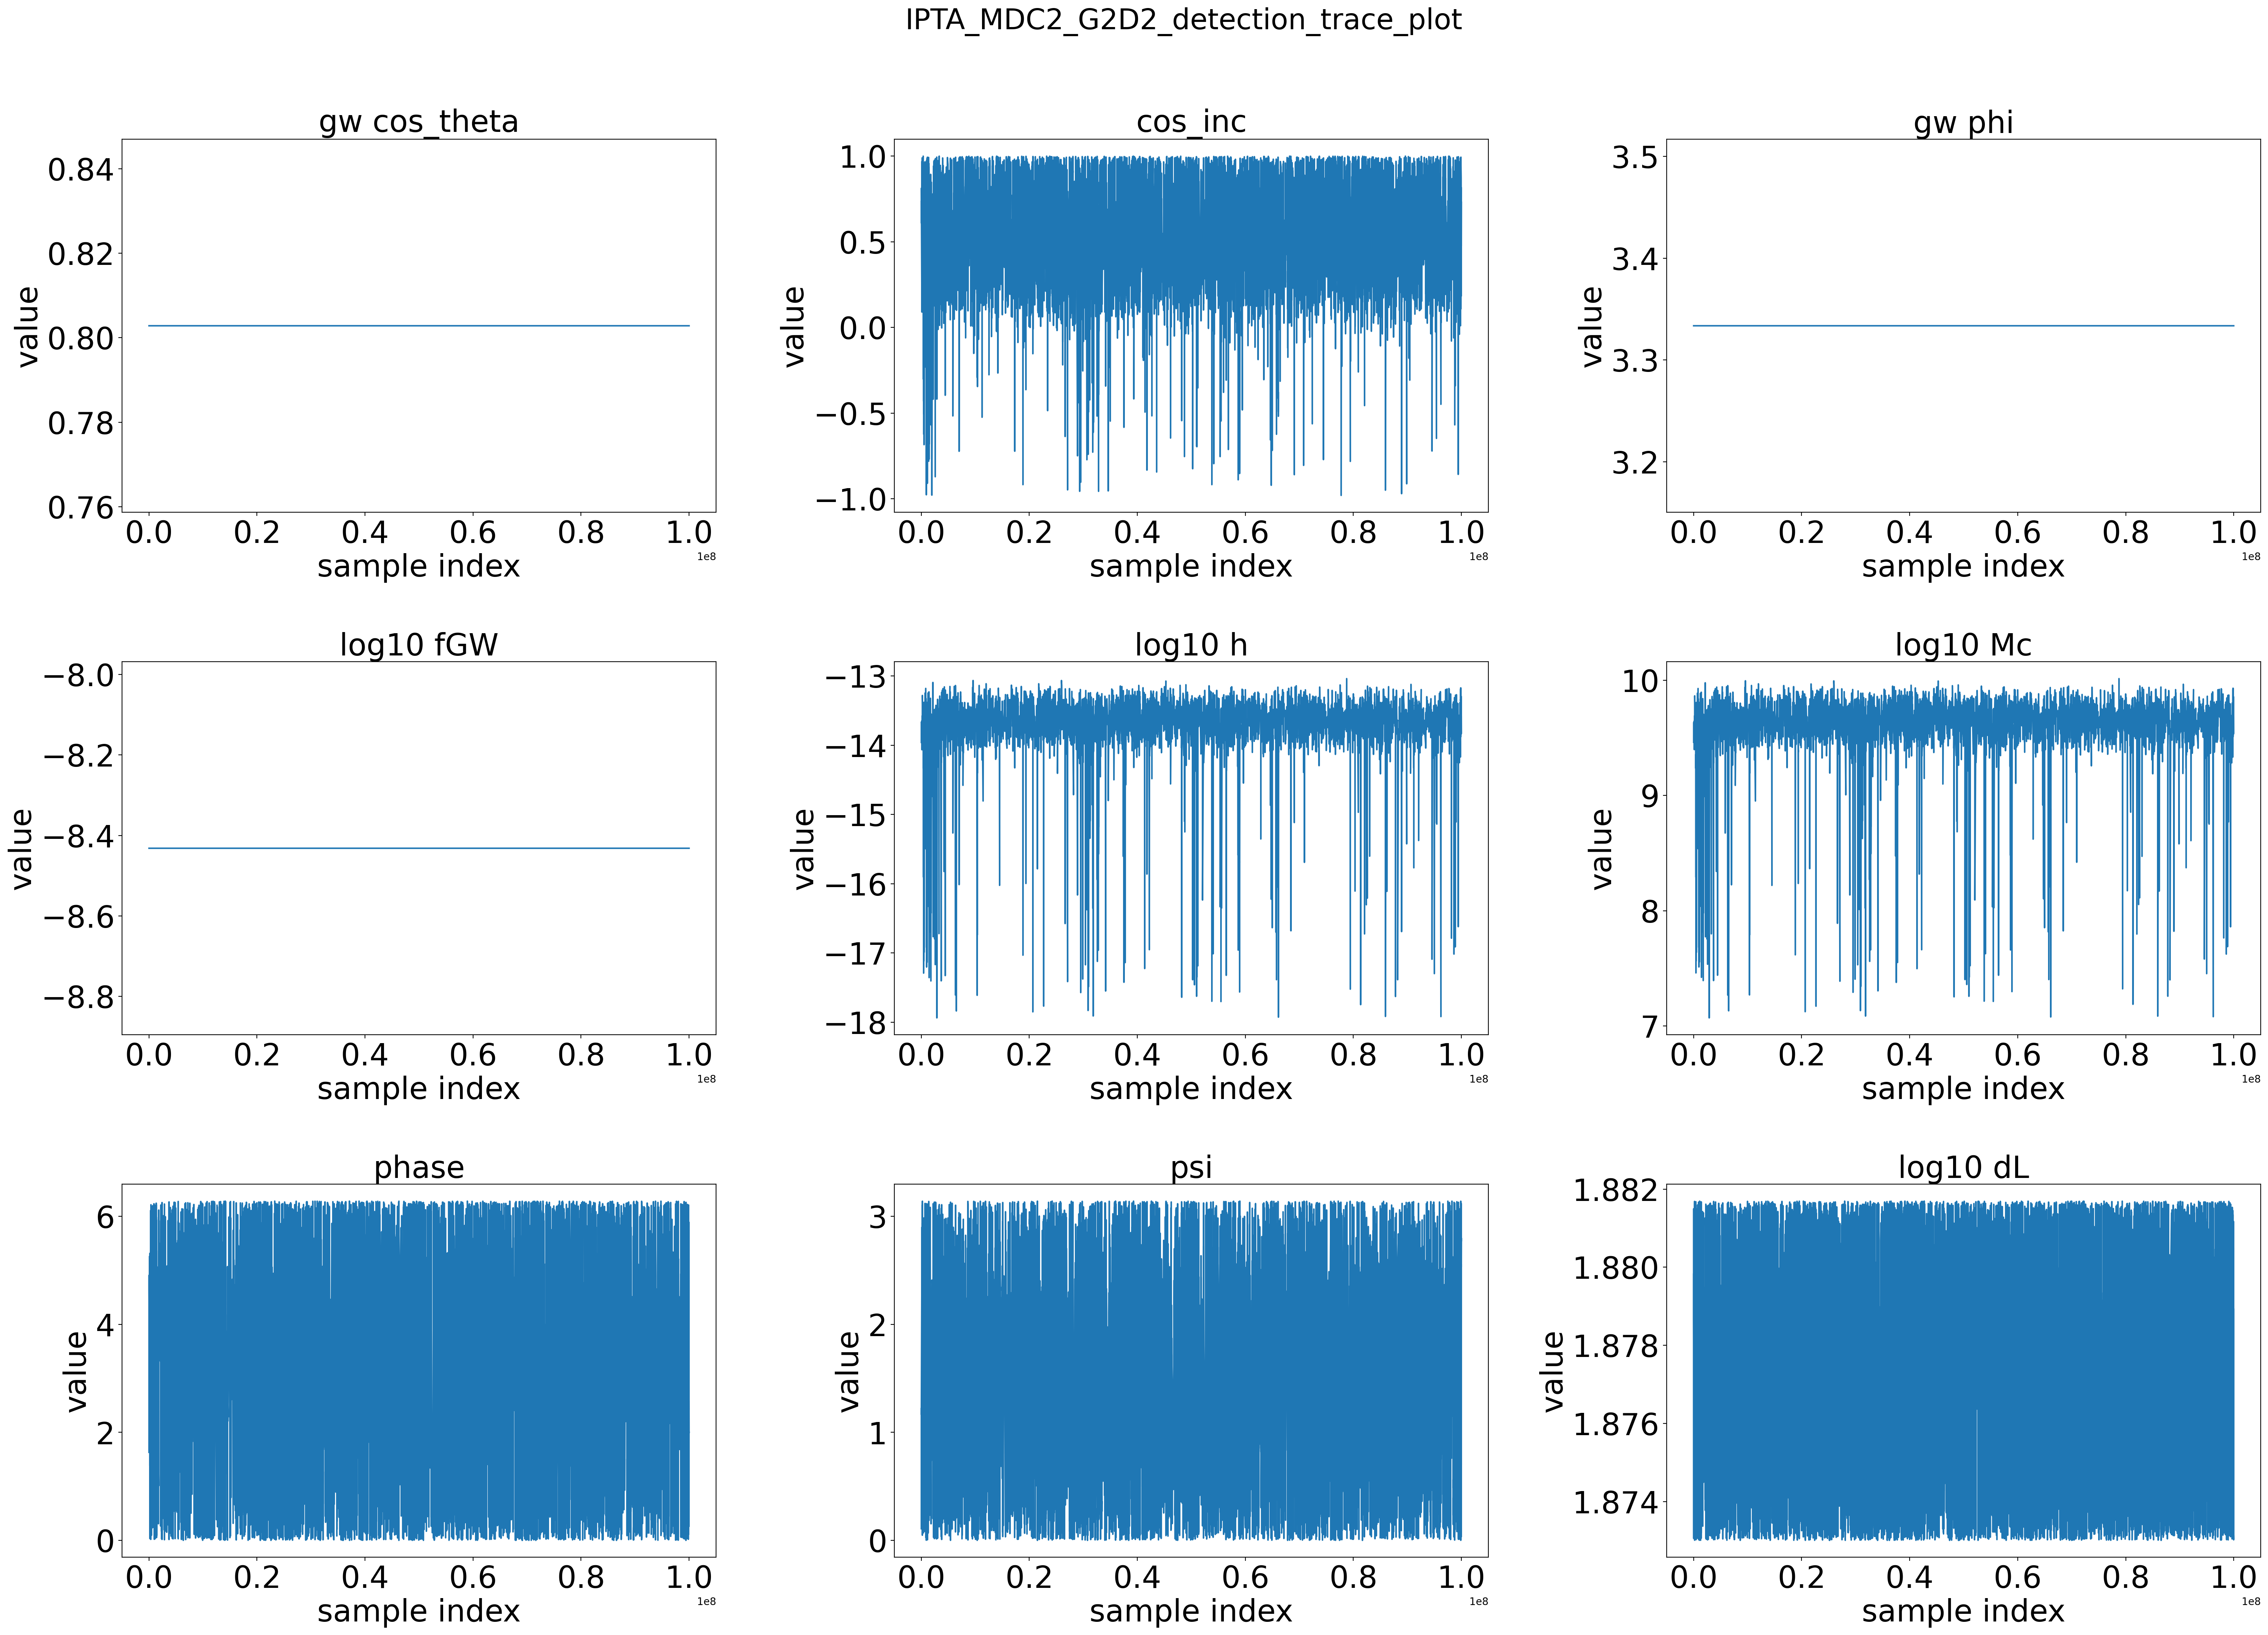

In [11]:
import matplotlib.pyplot as plt

title = ["gw cos_theta", "cos_inc", "gw phi", "log10 fGW", 
         "log10 h", "log10 Mc", "phase", "psi", "log10 dL"]

j = -1
row, column = 3, 3
fig, axs = plt.subplots(row, column, figsize=(30, 20))
fig.tight_layout(h_pad=3, w_pad=2)

# Loop over parameters
for i in range(len(title)): 
    if i % column == 0:
        j += 1
    axs[j, i % column].plot(d_L_mask, samples2plot[d_L_mask, i])
    axs[j, i % column].set_title(title[i], fontsize=30)    # bigger subplot title
    axs[j, i % column].tick_params(axis="both", labelsize=30)  # bigger tick labels
    axs[j, i % column].set_xlabel("sample index", fontsize=30)
    axs[j, i % column].set_ylabel("value", fontsize=30)

# Global title
fig.suptitle(trace_plot_title, fontsize=28, y=1.08)

plt.subplots_adjust(hspace=0.4, wspace=0.3)  # more spacing
#plt.show()
#plt.savefig("trace_plots.png", dpi=200, bbox_inches="tight")


In [12]:
print(np.min(samples2plot[d_L_mask,5]))
print(np.max(np.log10(samples2plot[d_L_mask,5])))

7.0708666e+00
1.0005852


## SD BF

hmin -17.937511
hmax -13.037067
Mc min 7.0708666
Mc max 10.013484
118567


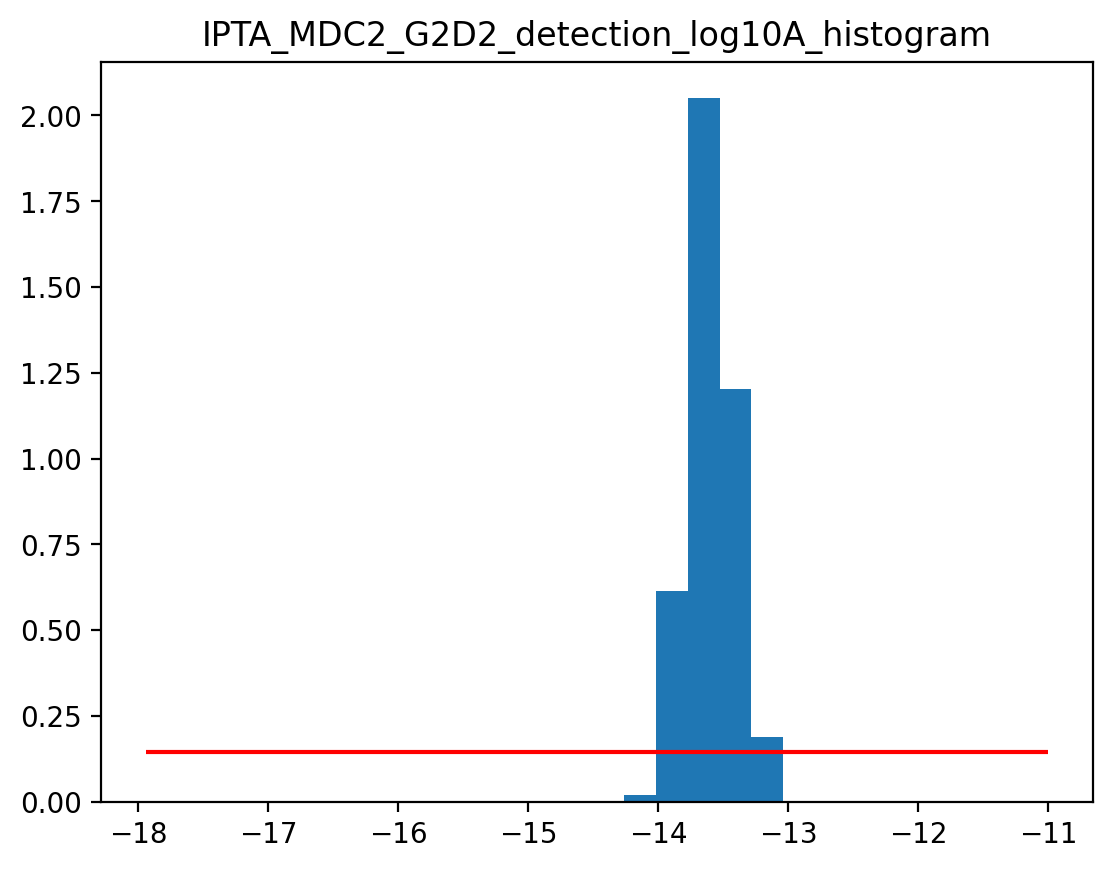

In [13]:
logAmin_dL = np.min(samples2plot[d_L_mask,4])
logAmax_dL = np.max(samples2plot[d_L_mask,4])
print("hmin",logAmin_dL)
print("hmax",logAmax_dL)
print("Mc min",np.min(samples2plot[d_L_mask,5]))
print("Mc max",np.max(samples2plot[d_L_mask,5]))

print(len(samples2plot[d_L_mask,4]))

plt.hist(samples2plot[d_L_mask,4], bins=20, density=True)
plt.hlines(1/(-11 - logAmin_dL), logAmin_dL, -11,  color='red')
plt.title(BF_histogram_title)
plt.show()

/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


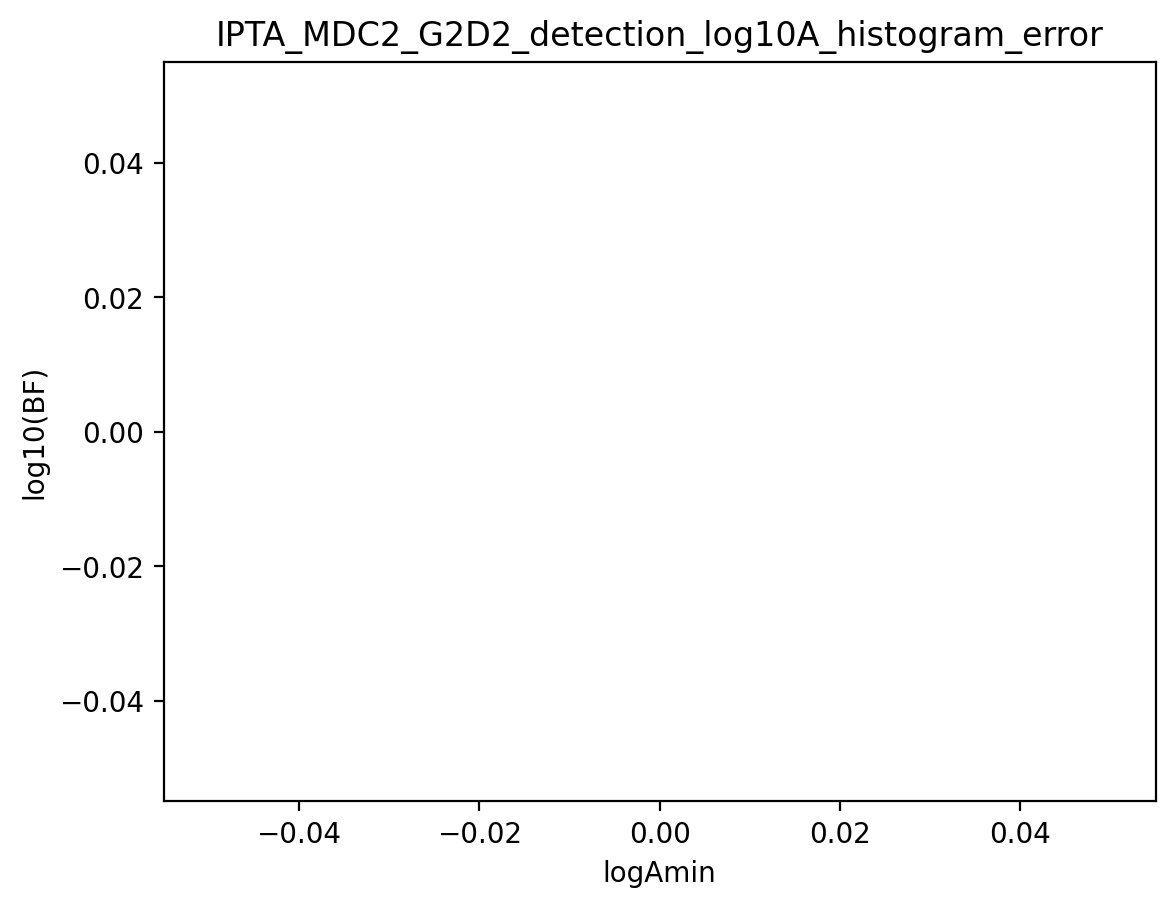

In [14]:
#d_L correlated SD BF
logamins = np.linspace(logAmin_dL, -15, 100)
BF_arr = []
BF_err_arr = []

from enterprise_extensions import model_utils
for logamin in logamins:
    BF,BF_err = model_utils.bayes_fac(samples = samples2plot[d_L_mask,4], logAmin=logamin, logAmax=-11)
    BF_arr.append(BF)
    BF_err_arr.append(BF_err)

plt.errorbar(logamins, BF_arr, yerr=BF_err_arr, fmt='o')
plt.xlabel('logAmin')
plt.ylabel("log10(BF)")
plt.title(BFerr_title)
plt.show()

In [15]:
#d_L correlated SD BF
BF, BF_err = model_utils.bayes_fac(samples=samples2plot[d_L_mask,4], logAmax=-11)
print(f"log10A BF = {BF:.4f} ± {BF_err:.4f}")

log10A BF = nan ± nan


/usr/local/anaconda/lib/python3.9/site-packages/enterprise_extensions/model_utils.py:194: RuntimeWarning: divide by zero encountered in double_scalars
  bf.append(prior/post)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: i

In [16]:
#Non d_L correlated SD BF
from enterprise_extensions import model_utils
BF,BF_err = model_utils.bayes_fac(samples = samples_cold[0][::10,4], logAmax=-11)
print(f"log10A BF = {BF:.4f} ± {BF_err:.4f}")

log10A BF = 389.2687 ± 5.3318


In [17]:
print(BF_arr[0:10])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [18]:
print(BF_err_arr[0:10])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [19]:
import numpy as np
wrap = lambda x,P: x % P
def angdiff(a,b,P): return ((a-b + P/2) % P) - P/2

# --- pull masked samples ---
phi  = samples_cold[0][burnin::thin, 6][d_L_mask]    # 0_phase0
psi  = samples_cold[0][burnin::thin, 7][d_L_mask]    # 0_psi
log10f = samples_cold[0][burnin::thin, 3][d_L_mask]  # 0_log10_fgw

# --- injected parameters ---
phi_inj = 0.24434609527920614  # radians
tref_inj_mjd = 55443.93364609394
tref_qcw_mjd  = tref_inj_mjd   # if this chain used fixed tref

# --- 1) canonicalize each sample to one branch: ψ∈[0,π/2), φ0∈[0,π) ---
phi = wrap(phi, 2*np.pi); psi = wrap(psi, np.pi)
mask = psi >= np.pi/2
psi_c = np.where(mask, psi - np.pi/2, psi)
phi_c = np.where(mask, wrap(-phi, 2*np.pi), phi)
phi_c = np.where(phi_c >= np.pi, phi_c - np.pi, phi_c)  # fold to [0,π)

# circular mean for φ0 on this branch
phi_mean = wrap(np.angle(np.mean(np.exp(1j*phi_c))), 2*np.pi)
if phi_mean >= np.pi:  # keep in [0,π)
    phi_mean -= np.pi

# --- 2) tref shift using recovered f ---
f_rec = 10**np.median(log10f)
dt_sec = (tref_qcw_mjd - tref_inj_mjd)*86400.0
dphi_pred = wrap(2*np.pi*f_rec*dt_sec, 2*np.pi)

# --- 3) expected φ0 on the same branch (ψ→ψ-π/2, φ0→-φ0) ---
phi_inj_B = wrap(-phi_inj, 2*np.pi)
if phi_inj_B >= np.pi:
    phi_inj_B -= np.pi

phi_expected = wrap(phi_inj_B + dphi_pred, 2*np.pi)
if phi_expected >= np.pi:                # fold like samples
    phi_expected -= np.pi

# --- 4) residual ---
resid = abs(angdiff(phi_mean, phi_expected, np.pi))  # compare on [0,π)
print("φ0 circular mean (canonical):", phi_mean)
print("Predicted tref shift Δφ:", dphi_pred)
print("Expected φ0 (same branch):", phi_expected)
print("Residual |Δ| on [0,π):", resid)


φ0 circular mean (canonical): 1.5677088499069214
Predicted tref shift Δφ: 0.0
Expected φ0 (same branch): 2.897246558310587
Residual |Δ| on [0,π): 1.3295377084036657


In [20]:
import numpy as np

wrap = lambda x,P: x % P

# recovered medians from your masked chain
phi_rec = np.median(samples_cold[0][burnin::thin, 6][d_L_mask])        # 0_phase0
log10f_rec = np.median(samples_cold[0][burnin::thin, 3][d_L_mask])      # 0_log10_fgw
f_rec = 10**log10f_rec

# injection info you have
phi_inj = 0.24434609527920614
tref_inj_mjd = 55443.93364609394
tref_qcw_mjd  = 53000.0   # the tref that produced the bad run

# predicted phase slip from tref *using recovered f*
dt = (tref_qcw_mjd - tref_inj_mjd)*86400.0
dphi_pred = wrap(2*np.pi*f_rec*dt, 2*np.pi)

print("phi_rec =", phi_rec)
print("f_rec   =", f_rec)
print("Δφ_pred (using f_rec) =", dphi_pred)


phi_rec = 3.222269
f_rec   = 3.7000025104678226e-09
Δφ_pred (using f_rec) = 1.3742756440206243
